# Netflix Data Analysis using Python

## Objective

The objective of this project is to perform **Exploratory Data Analysis (EDA)** on the Netflix Titles dataset using Python. The analysis helps understand the distribution of movies and TV shows, identify popular content-producing countries, analyze release trends, and clean the dataset for meaningful insights.

### Problem Statement

Netflix has thousands of movies and TV shows from different countries, genres, and release years. This project explores the dataset to discover patterns and trends using data cleaning, statistical analysis, and visualization techniques.

# Step 1: Import Required Libraries

The required Python libraries are imported for:

- Reading the dataset
- Data manipulation
- Numerical calculations
- Creating visualizations
- Performing exploratory data analysis (EDA)

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore")

plt.style.use("ggplot")
sns.set(font_scale=1.1)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


# Step 2: Load Dataset

The Netflix dataset is loaded into a Pandas DataFrame using `read_csv()`.

The DataFrame stores the dataset in rows and columns, making it easy to analyze and manipulate.

In [26]:
df = pd.read_csv(r"C:\Users\sanja\OneDrive\Desktop\Netflix_Data\netflix_titles.csv\netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Step 3: Explore Dataset

The dataset structure is examined using:

- Shape
- Column names
- Data types
- Non-null values

This helps understand the dataset before performing data cleaning.

In [27]:
print("Shape of Dataset :", df.shape)
print("\nColumns:\n")
print(df.columns)

print("\nInformation:\n")
df.info()

Shape of Dataset : (8807, 12)

Columns:

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


# Step 4: Check Missing Values

Missing values are identified using `isnull().sum()`.

Identifying null values is an important preprocessing step before performing data analysis.

In [28]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


# Step 5: Handle Missing Values

Missing values in categorical columns are replaced with **"Unknown"**.

This preserves the dataset while ensuring there are no null values in these columns.

In [29]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

df.dropna(inplace=True)

print("Remaining Missing Values")
print(df.isnull().sum())

Remaining Missing Values
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


# Step 6: Remove Duplicate Records

Duplicate rows are identified and removed to ensure that the dataset contains unique observations.

In [30]:
print("Duplicate Rows :", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Rows After Removing Duplicates :", len(df))

Duplicate Rows : 0
Rows After Removing Duplicates : 8794


# Step 7: Statistical Summary

The statistical summary provides descriptive information about both numerical and categorical columns, helping understand the overall characteristics of the dataset.

In [31]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8794,8794,8794,8794,8794,8794,8794,8794.000000,8794,8794,8794,8794
unique,8794,2,8794,4528,7682,749,1766,NaN,14,220,513,8762
top,s1,Movie,Dick Johnson Is Dead,Unknown,Unknown,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6128,1,2624,825,2809,109,NaN,3209,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.183534,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.823527,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


# Step 8: Content Type Distribution

A count plot is used to compare the number of Movies and TV Shows available on Netflix.

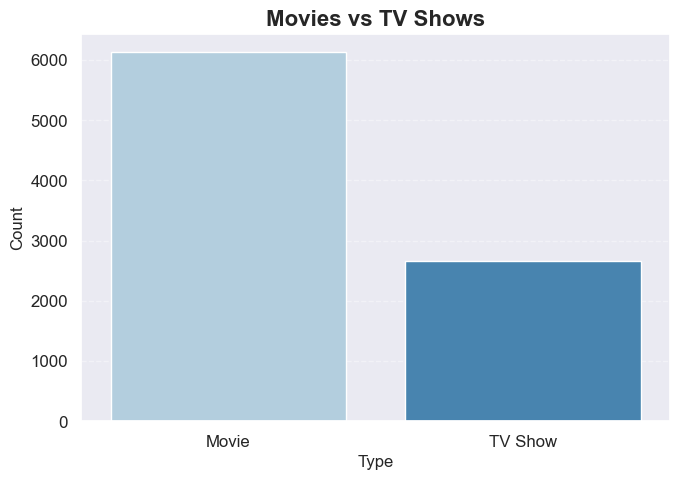

In [32]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df,x="type", palette="Blues"
)

plt.title("Movies vs TV Shows", fontsize=16, fontweight="bold")
plt.xlabel("Type", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Step 9: Percentage Distribution of Content

A pie chart visualizes the percentage share of Movies and TV Shows in the Netflix dataset.

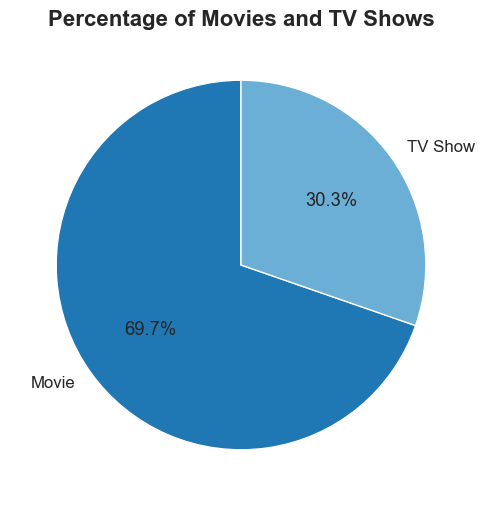

In [37]:
# Count Movies and TV Shows
type_counts = df["type"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(type_counts,labels=type_counts.index, autopct="%1.1f%%", startangle=90,
    colors=["#1f77b4", "#6baed6"])

plt.title("Percentage of Movies and TV Shows", fontsize=16, fontweight="bold")

plt.show()

# Step 10: Top 10 Content-Producing Countries

The top ten countries with the highest number of Netflix titles are identified and visualized to understand global content distribution.

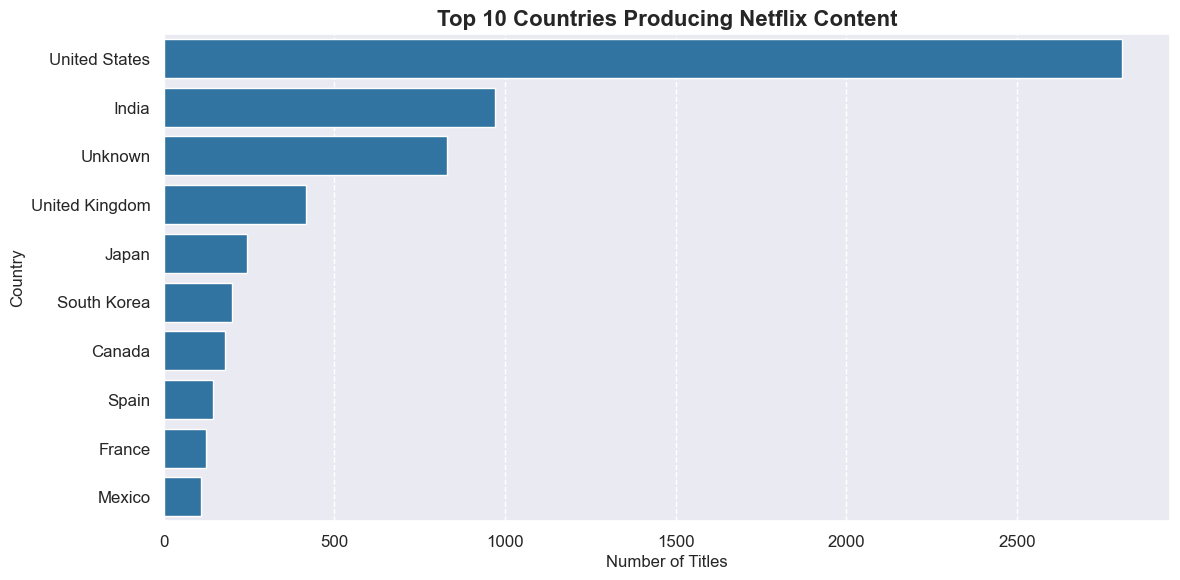

In [39]:
# Top 10 countries
top_country = df["country"].value_counts().head(10)

plt.figure(figsize=(12, 6))

sns.barplot( x=top_country.values, y=top_country.index, color="#1f77b4")

plt.title("Top 10 Countries Producing Netflix Content", fontsize=16, fontweight="bold")
plt.xlabel("Number of Titles", fontsize=12)
plt.ylabel("Country", fontsize=12)

plt.grid(axis="x", linestyle="--")

plt.tight_layout()
plt.show()

# Step 11: Top 10 Directors on Netflix

The top 10 directors with the highest number of Netflix titles are identified and visualized using a horizontal bar chart.

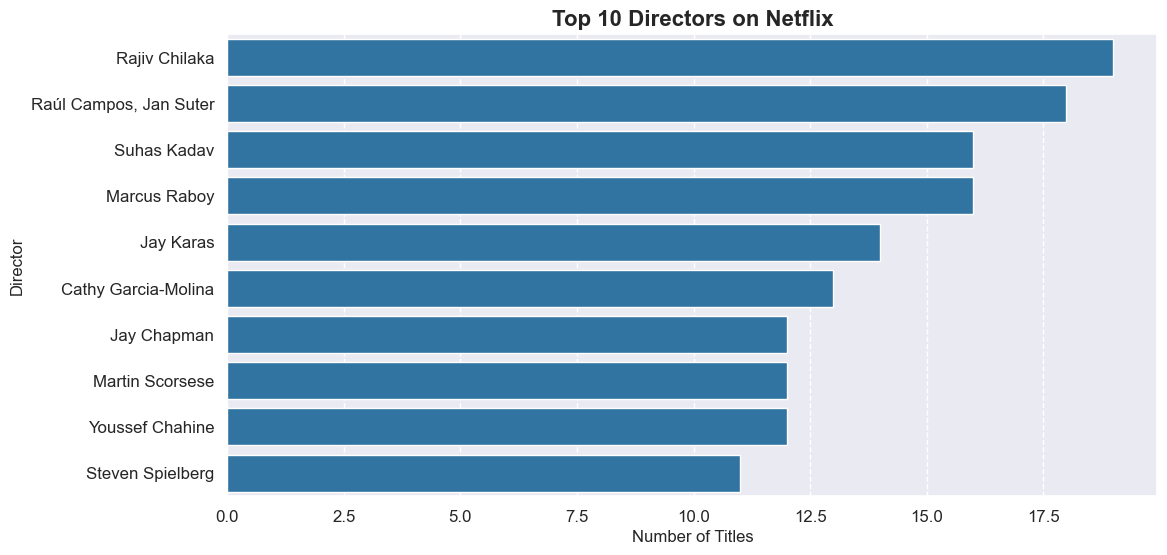

In [66]:
# Remove unknown directors
top_directors = (
    df[df["director"] != "Unknown"]["director"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index,
    color="#1f77b4"
)

plt.title("Top 10 Directors on Netflix", fontsize=16, fontweight="bold")
plt.xlabel("Number of Titles", fontsize=12)
plt.ylabel("Director", fontsize=12)

plt.grid(axis="x", linestyle="--")

plt.show()

# Step 12: Content Rating Distribution

A count plot is used to visualize the distribution of Netflix titles across different content ratings.

The ratings are displayed in descending order based on the number of titles, making it easier to identify the most common audience classifications on Netflix.

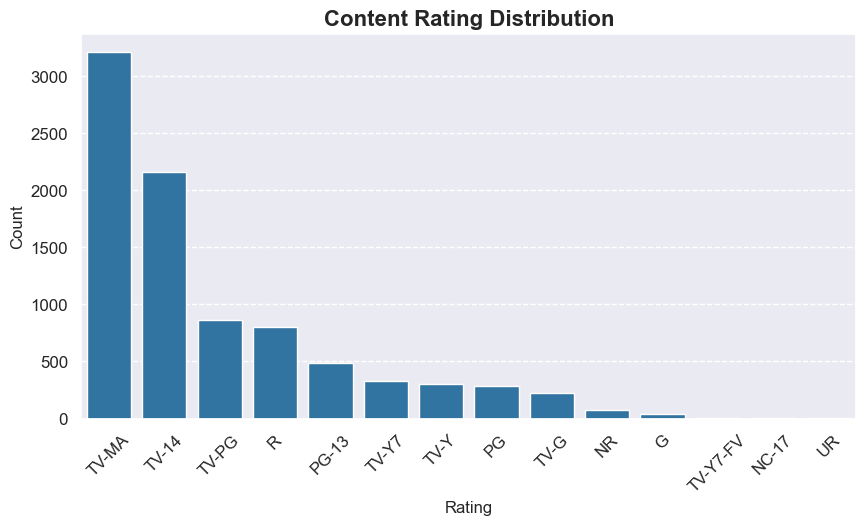

In [65]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="rating",
    order=df["rating"].value_counts().index,
    color="#1f77b4"
)

plt.xticks(rotation=45)

plt.title("Content Rating Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.grid(axis="y", linestyle="--")

plt.show()

# Step 13: Content Release Trend

The number of Netflix titles released each year is visualized to identify trends in content production over time.

This analysis helps understand how Netflix's content library has grown across different years.

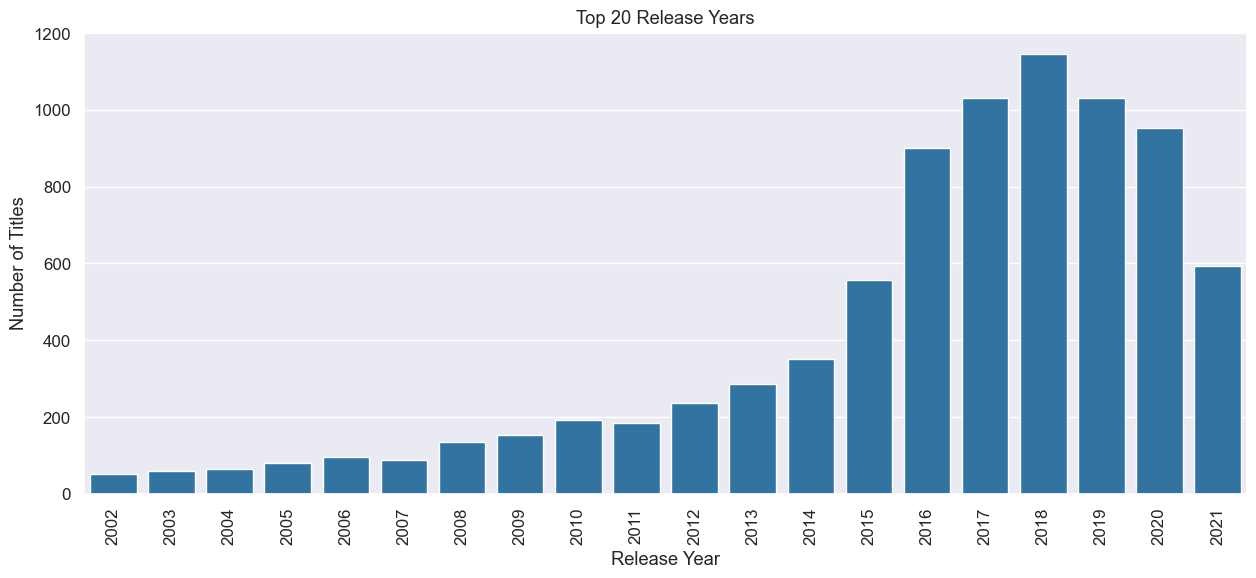

In [64]:
plt.figure(figsize=(15,6))

release = df["release_year"].value_counts().head(20)

sns.barplot(
    x=release.index,
    y=release.values,
    color="#1f77b4"
)

plt.xticks(rotation=90)

plt.title("Top 20 Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

# Step 14: Top 10 Genres

The `listed_in` column contains multiple genres for many titles.

The genres are separated into individual values using `split()` and `explode()`, allowing accurate counting of each genre.

The top 10 most common genres are then visualized to understand Netflix's most popular content categories.

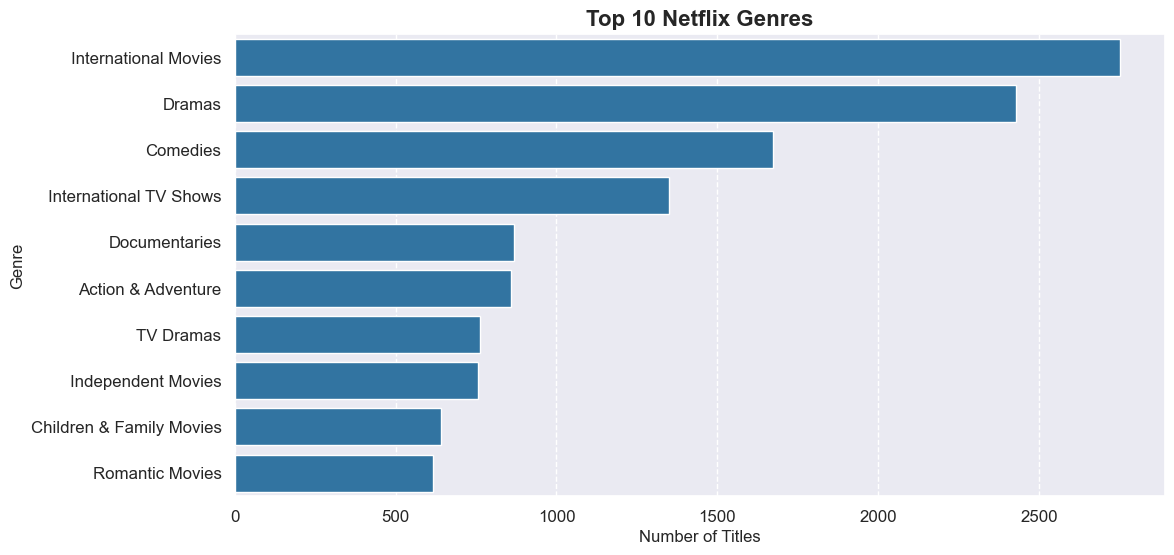

In [61]:
# Split genres into individual values
genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
)

# Top 10 genres
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    color="#1f77b4"
)

plt.title("Top 10 Netflix Genres", fontsize=16, fontweight="bold")
plt.xlabel("Number of Titles", fontsize=12)
plt.ylabel("Genre", fontsize=12)

plt.grid(axis="x", linestyle="--")

plt.show()

# Step 15: Top 10 Actors on Netflix

The frequency of each actor's appearance is calculated, and the top 10 actors with the highest number of Netflix titles are visualized.

This analysis highlights the actors who appear most frequently in the Netflix catalog.

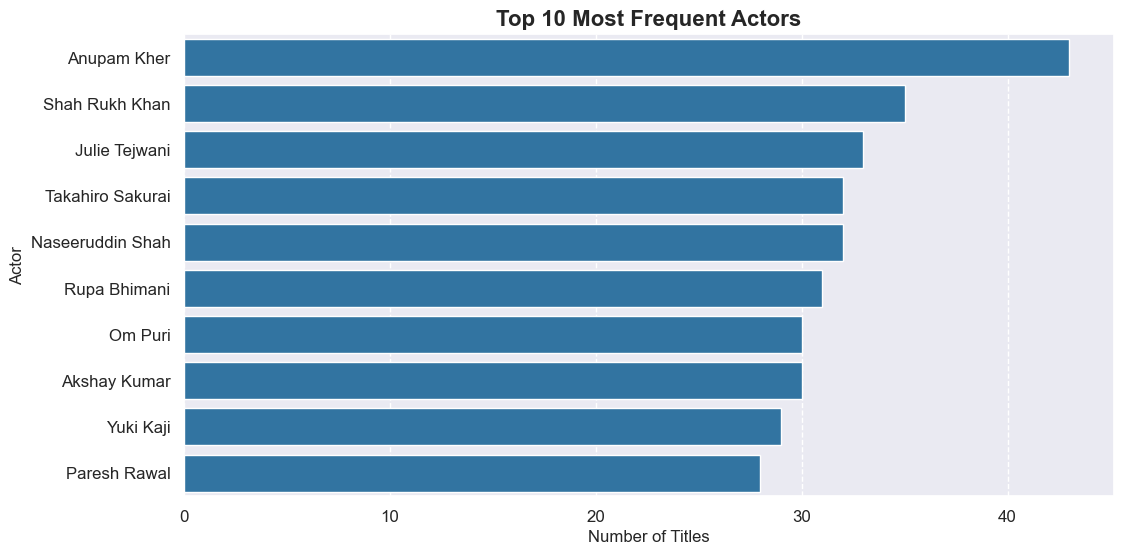

In [59]:
# Split cast into individual actors
actors = (
    df["cast"]
    .str.split(", ")
    .explode()
)

# Remove unknown actors
actors = actors[actors != "Unknown"]

# Top 10 actors
top_actors = actors.value_counts().head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_actors.values,
    y=top_actors.index,
    color="#1f77b4"
)

plt.title("Top 10 Most Frequent Actors", fontsize=16, fontweight="bold")
plt.xlabel("Number of Titles", fontsize=12)
plt.ylabel("Actor", fontsize=12)

plt.grid(axis="x", linestyle="--")

plt.show()

# Step 16: Top 10 Newest Movies

This analysis sorts the Netflix dataset by **release year** in descending order and displays the **10 most recently released movies or TV shows**.

The output helps identify the latest titles available in the dataset and provides an overview of the newest content added to Netflix.

In [73]:
latest = df.sort_values(
    "release_year",
    ascending=False
).head(10)

print(latest[["title","release_year"]])

                                     title  release_year
693                 Ali & Ratu Ratu Queens          2021
781  Black Holes | The Edge of All We Know          2021
762                           Sweet & Sour          2021
763                            Sweet Tooth          2021
764           Trippin' with the Kandasamys          2021
765                                 Xtreme          2021
766                Alan Saldaña: Locked Up          2021
767                   Creator's File: GOLD          2021
768                         Dancing Queens          2021
770              Myriam Fares: The Journey          2021


# Step 17: Movie vs TV Show Percentage

This pie chart visualizes the percentage distribution of **Movies** and **TV Shows** available on Netflix.

The chart helps compare the share of each content type, providing a clear overview of Netflix's content library composition.

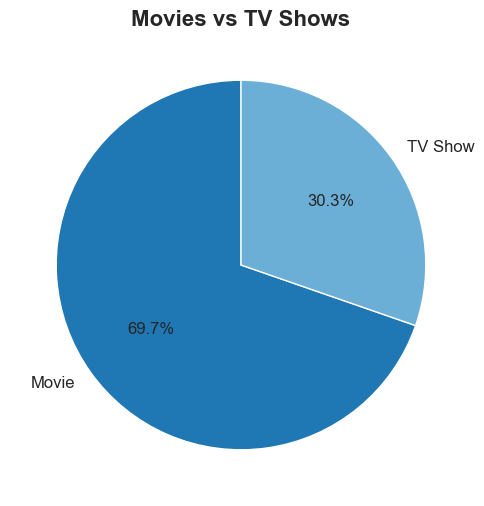

In [81]:
type_count = df["type"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    type_count,
    labels=type_count.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#1f77b4", "#6baed6"],
    textprops={"fontsize": 12}
)

plt.title("Movies vs TV Shows", fontsize=16, fontweight="bold")

plt.show()

# Step 18: Movies vs TV Shows by Country

This analysis groups Netflix titles by **country** and **content type (Movie or TV Show)**.

The top 10 countries with the highest number of movies are selected and visualized using a **grouped bar chart**, allowing an easy comparison between the number of Movies and TV Shows available in each country.

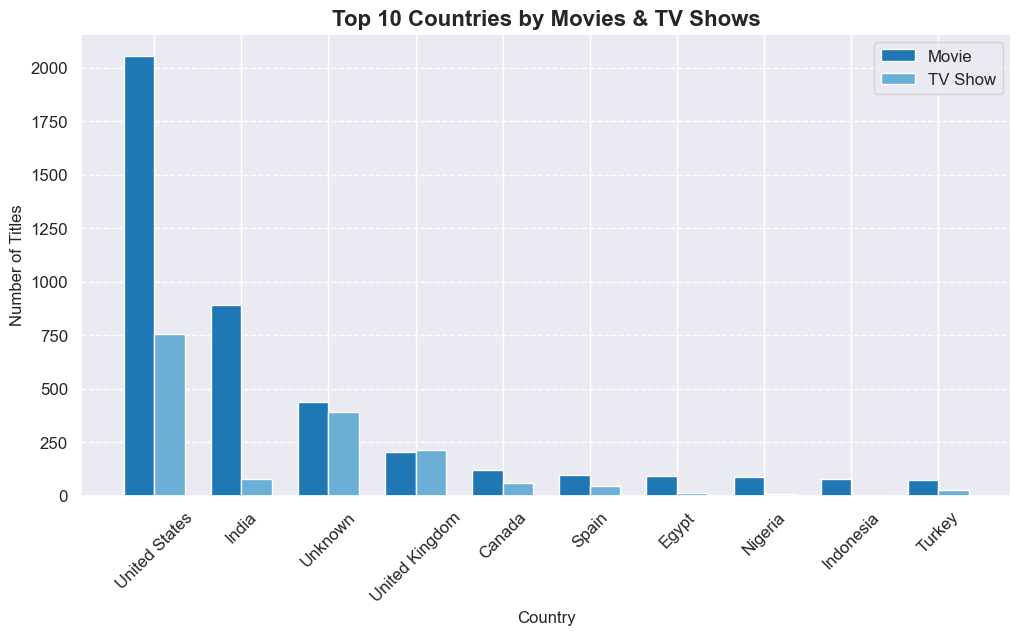

In [80]:
# Top 10 countries by Movies & TV Shows
country_type = (
    df.groupby(["country", "type"])
      .size()
      .unstack(fill_value=0)
      .sort_values(by="Movie", ascending=False)
      .head(10)
)

x = np.arange(len(country_type.index))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width/2,
    country_type["Movie"],
    width,
    label="Movie",
    color="#1f77b4",
)

plt.bar(
    x + width/2,
    country_type["TV Show"],
    width,
    label="TV Show",
    color="#6baed6",
)

plt.title("Top 10 Countries by Movies & TV Shows", fontsize=16, fontweight="bold")
plt.xlabel("Country", fontsize=12)
plt.ylabel("Number of Titles", fontsize=12)

plt.xticks(x, country_type.index, rotation=45)
plt.legend()

plt.grid(axis="y", linestyle="--")

plt.show()

# Business Insights

The analysis is summarized into business insights that describe important trends in the Netflix dataset.

These insights help understand:

- Content distribution
- Popular genres
- Major content-producing countries
- Frequently appearing directors and actors
- Growth of Netflix's content library over time

Such insights can support business decisions related to content acquisition and audience preferences.

In [56]:
print("="*60)
print("NETFLIX DATASET BUSINESS INSIGHTS")
print("="*60)

print("\n1. Movies dominate Netflix's catalog.")

print("\n2. TV-MA and TV-14 are the most common ratings.")

print("\n3. The United States contributes the highest number of titles.")

print("\n4. Netflix rapidly expanded its library after 2015.")

print("\n5. Drama, International Movies and Comedy are among the most popular genres.")

print("\n6. Most movies have durations between 80–120 minutes.")

print("\n7. Most TV Shows contain only one season.")

print("\n8. Certain directors and actors appear repeatedly, showing long-term collaborations.")

NETFLIX DATASET BUSINESS INSIGHTS

1. Movies dominate Netflix's catalog.

2. TV-MA and TV-14 are the most common ratings.

3. The United States contributes the highest number of titles.

4. Netflix rapidly expanded its library after 2015.

5. Drama, International Movies and Comedy are among the most popular genres.

6. Most movies have durations between 80–120 minutes.

7. Most TV Shows contain only one season.

8. Certain directors and actors appear repeatedly, showing long-term collaborations.


# Project Completion

The Netflix Exploratory Data Analysis project has been successfully completed.

The dataset has been cleaned, explored, visualized, and analyzed to generate meaningful insights about Netflix's content library.

The project demonstrates the complete EDA workflow, including data preprocessing, visualization, and interpretation of results.

In [58]:
print("="*60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*60)

print("""
Project Name:
Netflix Data Analysis using Python

Tools Used:
✔ Python
✔ Pandas
✔ NumPy
✔ Matplotlib
✔ Seaborn

Skills Demonstrated:
✔ Data Cleaning
✔ Data Manipulation
✔ Data Visualization
✔ Exploratory Data Analysis (EDA)
✔ Business Insights
✔ Feature Engineering

Key Findings

✔ Movies make up the majority of Netflix's content.
✔ The United States is the leading content-producing country.
✔ Drama and International Movies are among the most popular genres.
✔ Several directors and actors have contributed a significant number of titles.
✔ Netflix's content library has grown substantially over recent years.

Thank You!
""")

PROJECT COMPLETED SUCCESSFULLY

Project Name:
Netflix Data Analysis using Python

Tools Used:
✔ Python
✔ Pandas
✔ NumPy
✔ Matplotlib
✔ Seaborn

Skills Demonstrated:
✔ Data Cleaning
✔ Data Manipulation
✔ Data Visualization
✔ Exploratory Data Analysis (EDA)
✔ Business Insights
✔ Feature Engineering

Key Findings

✔ Movies make up the majority of Netflix's content.
✔ The United States is the leading content-producing country.
✔ Drama and International Movies are among the most popular genres.
✔ Several directors and actors have contributed a significant number of titles.
✔ Netflix's content library has grown substantially over recent years.

Thank You!

